# Transaction Amount Forecasting

The objective of this analysis is to determine whether historical transaction activity could be used to forecast future transaction values.

### Methodology
A daily transaction-level dataset to be aggregated to create a time-series of daily transaction values.

The following features engineered:
* Day of month
* Month
* Weekday
* Lag 1 day transaction value
* Lag 7 day transaction value

Then use Random Forest Regressor to train using historical patterns to predict future transaction values.

In [2]:
# Import Libararies
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# Load Data
transactions = pd.read_csv(
    "../data/clean/transactions.csv"
)

In [4]:
# Convert Date
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [5]:
# Create Daily Transaction Dataset
daily_txn = (
    transactions[
        transactions["transaction_status"]
        .isin(["Completed", "Pending"])
    ]
    .groupby("transaction_date")
    .agg(
        daily_value=("amount_gbp", "sum"),
        daily_transactions=("transaction_id", "count")
    )
    .reset_index()
)

In [6]:
daily_txn.head()

,transaction_date,daily_value,daily_transactions
0,2026-01-01,218.50,3
1,2026-01-02,1263.02,7
2,2026-01-03,377.09,3
3,2026-01-04,224.30,3
4,2026-01-05,29.88,1


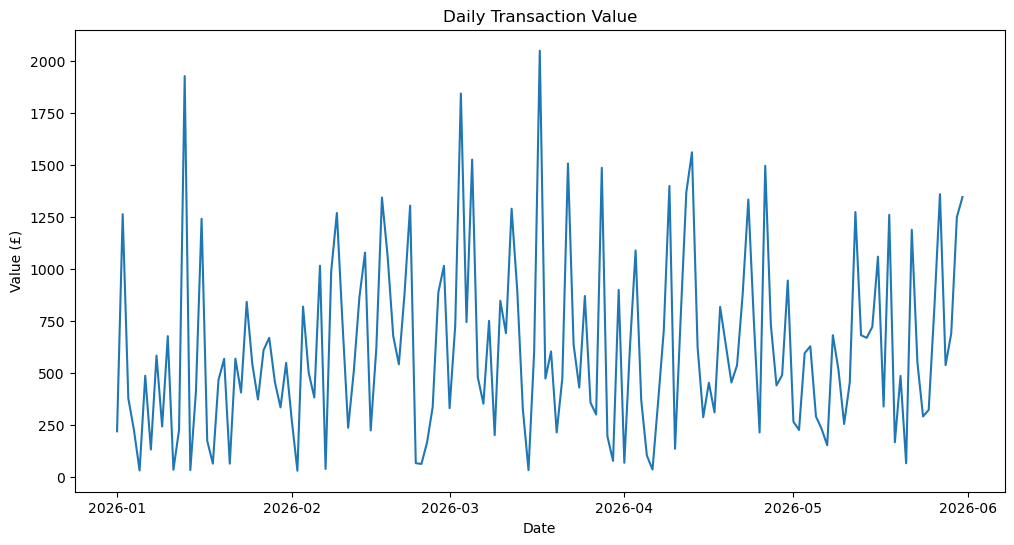

In [7]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_txn["transaction_date"],
    daily_txn["daily_value"]
)

plt.title(
    "Daily Transaction Value"
)

plt.xlabel("Date")
plt.ylabel("Value (£)")

plt.show()

In [8]:
# Create Time Features
daily_txn["day"] = (
    daily_txn["transaction_date"]
    .dt.day
)

daily_txn["month"] = (
    daily_txn["transaction_date"]
    .dt.month
)

daily_txn["weekday"] = (
    daily_txn["transaction_date"]
    .dt.dayofweek
)

In [9]:
# Lag Features
daily_txn["lag_1"] = (
    daily_txn["daily_value"]
    .shift(1)
)

daily_txn["lag_7"] = (
    daily_txn["daily_value"]
    .shift(7)
)

In [10]:
# Rolling Averages
daily_txn["rolling_7"] = (
    daily_txn["daily_value"]
    .rolling(7)
    .mean()
)

# Remove nulls
daily_txn = daily_txn.dropna()

In [11]:
# Feature Matrix
X = daily_txn[
    [
        "daily_transactions",
        "day",
        "month",
        "weekday",
        "lag_1",
        "lag_7",
        "rolling_7"
    ]
]

y = daily_txn["daily_value"]

In [12]:
# Train/Test Split
split_index = int(
    len(daily_txn) * 0.8
)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [13]:
# Train the model
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

In [14]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)


In [15]:
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²:", round(r2,4))

MAE: 207.2
RMSE: 245.74
R²: 0.5956


#### Model Performance Assessment
|**Metric**|**Result**|**Interpretation**|
|----------|----------|------------------|
|MAE|207.20|Forecast misses ~£207 on average|
|RMSE|245.74|Larger errors are present but not extreme|
|R$^2$|0.596|Model explains ~60% of transaction value variation|
|Overall|Good|Useful forecasting model, not overfitted|

In [17]:
# Feature Importance
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

importance_df

,feature,importance
0,daily_transactions,0.489463
5,lag_7,0.184556
6,rolling_7,0.104727
4,lag_1,0.072998
1,day,0.072009
3,weekday,0.044999
2,month,0.031249


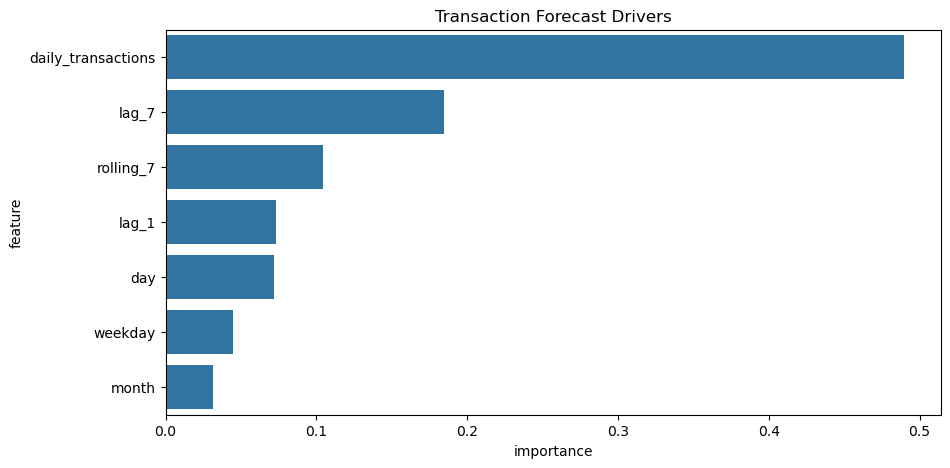

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title(
    "Transaction Forecast Drivers"
)

plt.show()

#### Feature Importance Interpretation
* Transaction count is the strongest driver of transaction value.
Nearly 50% of predictive power comes from the number of transactions processed on a given day.

Implication:
> Growth in transaction volume has a stronger effect on total value than seasonal calendar effects.

* Weekly behavioral patterns exist.
Lag 7 and Rolling 7 together contribute

18.5% + 10.5% = 29.0%

This suggests customers behave similarly week-to-week.

Implication:
> Historical weekly activity is a strong indicator of future transaction value

* Day-of-week effects are relatively week

weekday = 4.5%

month = 3.1%

Implication:
> The synthetic data does not contain strong seasonality.

This is expected because the dataset spans only Jan-May 2026.

In [20]:
forecast_results = pd.DataFrame({
    "date":
        daily_txn.iloc[
            split_index:
        ]["transaction_date"],
    "actual":
        y_test,
    "predicted":
        predictions
})

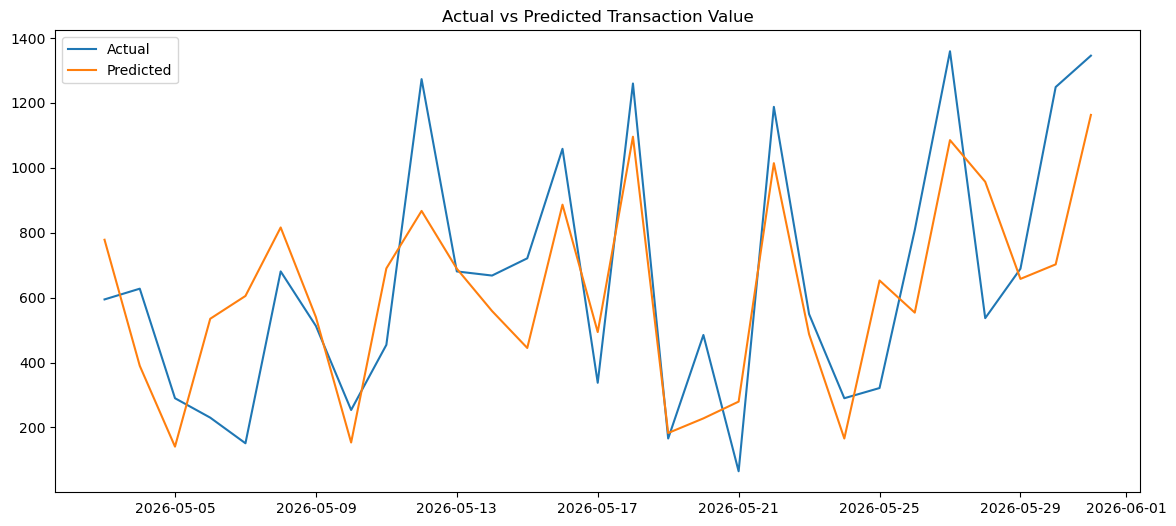

In [21]:
plt.figure(figsize=(14,6))

plt.plot(
    forecast_results["date"],
    forecast_results["actual"],
    label="Actual"
)

plt.plot(
    forecast_results["date"],
    forecast_results["predicted"],
    label="Predicted"
)

plt.legend()

plt.title(
    "Actual vs Predicted Transaction Value"
)

plt.show()

While the model successfully captures overall transaction trends, it tended to underestimate extreme transaction spiked, suggesting that additional external features could further improve forecasting performance.

In [23]:
# Store historical daily data
historical_data = daily_txn.copy()

historical_data.tail()

,transaction_date,daily_value,daily_transactions,day,month,weekday,lag_1,lag_7,rolling_7
145,2026-05-27,1359.13,6,27,5,2,808.27,484.85,654.360000
146,2026-05-28,536.74,4,28,5,3,1359.13,64.83,721.775714
147,2026-05-29,689.00,4,29,5,4,536.74,1187.85,650.511429
148,2026-05-30,1248.92,4,30,5,5,689.00,549.13,750.481429
149,2026-05-31,1345.61,6,31,5,6,1248.92,289.94,901.291429


In [24]:
# create future dates
future_dates = pd.date_range(
    start=historical_data["transaction_date"].max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_dates

DatetimeIndex(['2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04',
               '2026-06-05', '2026-06-06', '2026-06-07', '2026-06-08',
               '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12',
               '2026-06-13', '2026-06-14', '2026-06-15', '2026-06-16',
               '2026-06-17', '2026-06-18', '2026-06-19', '2026-06-20',
               '2026-06-21', '2026-06-22', '2026-06-23', '2026-06-24',
               '2026-06-25', '2026-06-26', '2026-06-27', '2026-06-28',
               '2026-06-29', '2026-06-30'],
              dtype='datetime64[ns]', freq='D')

In [25]:
forecast_df = pd.DataFrame({
    "transaction_date": future_dates
})

forecast_df

,transaction_date
0,2026-06-01
1,2026-06-02
2,2026-06-03
3,2026-06-04
4,2026-06-05
5,2026-06-06
6,2026-06-07
7,2026-06-08
8,2026-06-09
9,2026-06-10


In [26]:
# use historical values as seed
forecast_history = historical_data.copy()

future_predictions = []

In [27]:
# Generate 30-day forecast
for forecast_date in future_dates:

    lag_1 = forecast_history["daily_value"].iloc[-1]

    lag_7 = forecast_history["daily_value"].iloc[-7]

    rolling_7 = (
        forecast_history["daily_value"]
        .tail(7)
        .mean()
    )

    feature_row = pd.DataFrame({
        "daily_transactions": [
            forecast_history["daily_transactions"].tail(7).mean()
        ],
        "day": [forecast_date.day],
        "month": [forecast_date.month],
        "weekday": [forecast_date.dayofweek],
        "lag_1": [lag_1],
        "lag_7": [lag_7],
        "rolling_7": [rolling_7]
    })

    prediction = rf.predict(feature_row)[0]

    future_predictions.append(prediction)

    new_row = pd.DataFrame({
        "transaction_date": [forecast_date],
        "daily_value": [prediction],
        "daily_transactions": [
            forecast_history["daily_transactions"].tail(7).mean()
        ]
    })

    forecast_history = pd.concat(
        [forecast_history, new_row],
        ignore_index=True
    )

In [28]:
# create forecast table
forecast_df["forecast_value"] = future_predictions

forecast_df.head()

,transaction_date,forecast_value
0,2026-06-01,1109.255767
1,2026-06-02,884.911833
2,2026-06-03,786.160100
3,2026-06-04,850.364367
4,2026-06-05,926.043267


In [29]:
forecast_df.describe()

,transaction_date,forecast_value
count,30,30.000000
mean,2026-06-15 12:00:00,890.448297
min,2026-06-01 00:00:00,662.982000
25%,2026-06-08 06:00:00,855.474175
50%,2026-06-15 12:00:00,915.648400
75%,2026-06-22 18:00:00,930.623992
max,2026-06-30 00:00:00,1109.255767
std,NaN,81.030130


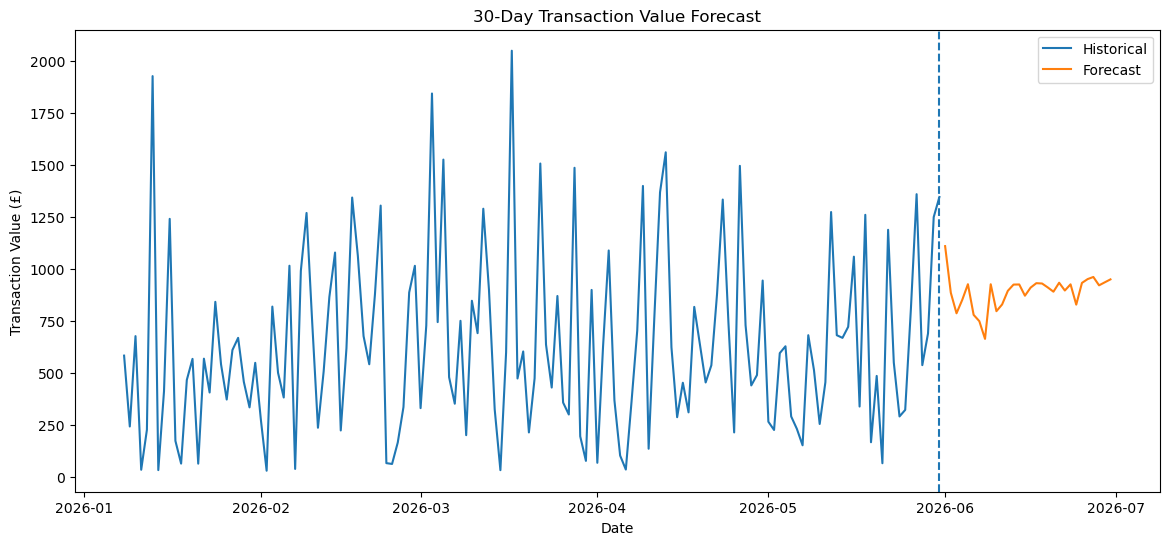

In [30]:
plt.figure(figsize=(14,6))

plt.plot(
    historical_data["transaction_date"],
    historical_data["daily_value"],
    label="Historical"
)

plt.plot(
    forecast_df["transaction_date"],
    forecast_df["forecast_value"],
    label="Forecast"
)

plt.axvline(
    historical_data["transaction_date"].max(),
    linestyle="--"
)

plt.title(
    "30-Day Transaction Value Forecast"
)

plt.xlabel("Date")
plt.ylabel("Transaction Value (£)")

plt.legend()

plt.show()

#### Forecast Review
The 30-day forecast produced relatively stable future values between **£700 and £1000 per day**.

However, historical transaction activity exhibited substantial volatility, with frequent spikes above **£1500-£2000** and occasional very low transaction days.

As a result, the model tends to smooth fluctuations rather than accurately forecast extreme movements.

### Conclusion
The foreccasting model provides directional insight but is not sufficiently accurate for operational forecasting or financial planning purposes.

Several factors likely contributed to the limited predictive performance:
* Short historical period (5 months)
* High variability in daily transaction values
* Lack of strong trend or seasonality